<a href="https://colab.research.google.com/github/fathurencuy/CNN-Cifar10/blob/main/FInal_Project_CNN_Cifar_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# Load dataset
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

# Normalisasi
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encoding
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1141s 7us/step


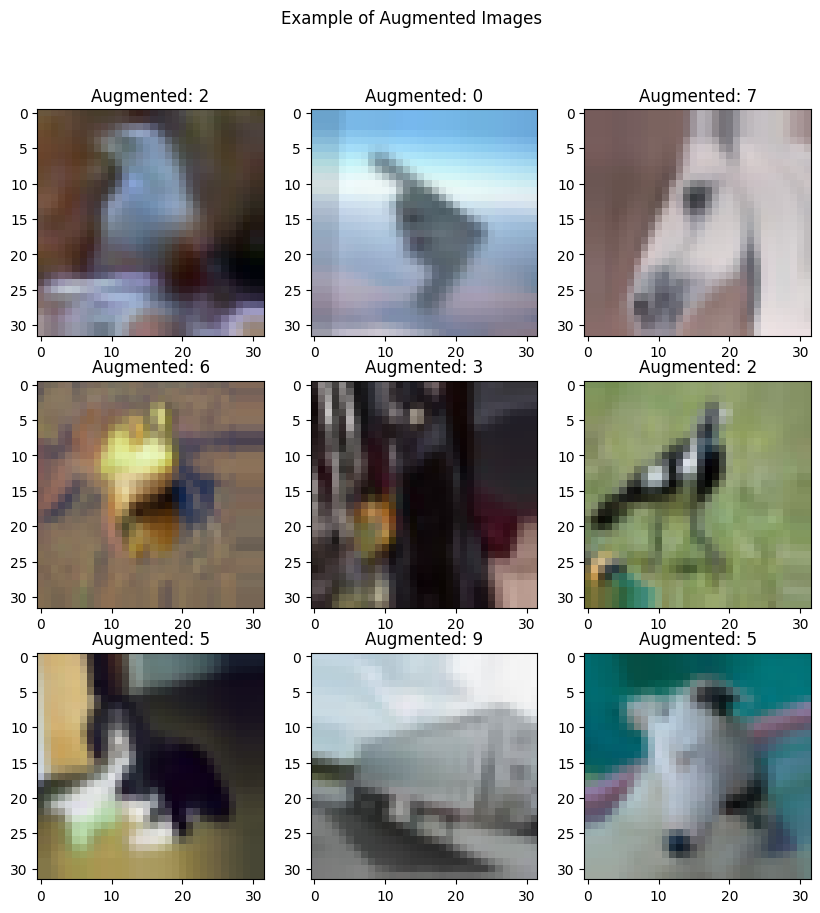

In [ ]:
#Augmentasi Data

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)


datagen.fit(X_train)


Y_train_int = np.argmax(Y_train, axis=1)

plt.figure(figsize=(10, 10))
for X_batch, Y_batch in datagen.flow(X_train, Y_train_int, batch_size=9):
    for i in range(0, 9):
        plt.subplot(330 + 1 + i)
        plt.imshow(X_batch[i])
        plt.title(f"Augmented: {Y_batch[i]}")
    plt.suptitle("Example of Augmented Images")
    plt.show()
    break

In [ ]:
#Pembuatan Layer Model
import tensorflow.keras as keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


history = model.fit(
    datagen.flow(X_train, Y_train,
    batch_size=128),
    validation_data=(X_test, Y_test),
    epochs=30,
    callbacks=[early_stopping,reduce_lr],
    verbose=1
)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.4111 - loss: 1.6195 - val_accuracy: 0.2570 - val_loss: 2.5627 - learning_rate: 0.0010
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.5537 - loss: 1.2475 - val_accuracy: 0.5909 - val_loss: 1.1725 - learning_rate: 0.0010
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.6109 - loss: 1.0970 - val_accuracy: 0.6191 - val_loss: 1.1196 - learning_rate: 0.0010
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.6525 - loss: 0.9949 - val_accuracy: 0.6432 - val_loss: 1.0782 - learning_rate: 0.0010
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.6784 - loss: 0.9262 - val_accuracy: 0.6255 - val_loss: 1.2327 - learning_rate: 0.0010
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.7008 - loss: 0.8633 - val_accuracy: 0.6905 - val_loss: 0.9155 - learning_rate: 0.0010
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.7211 - 

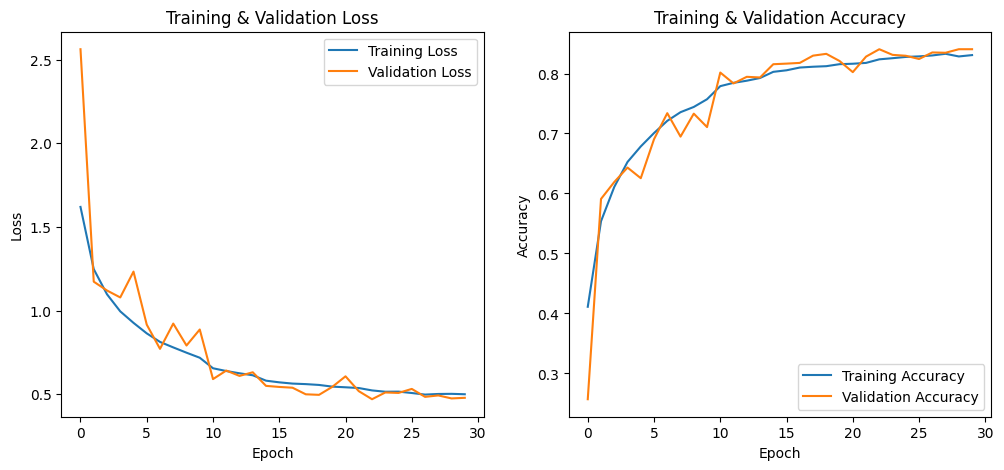

In [ ]:
# Visualisasi Hasil Training
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

plt.show()

In [ ]:
# Evaluasi Model
test_loss, test_acc = model.evaluate(X_test, Y_test)

print("Test Loss :", test_loss)
print(f"Test Accuracy : {test_acc:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8405 - loss: 0.4694
Test Loss : 0.46942225098609924
Test Accuracy : 84.05%


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


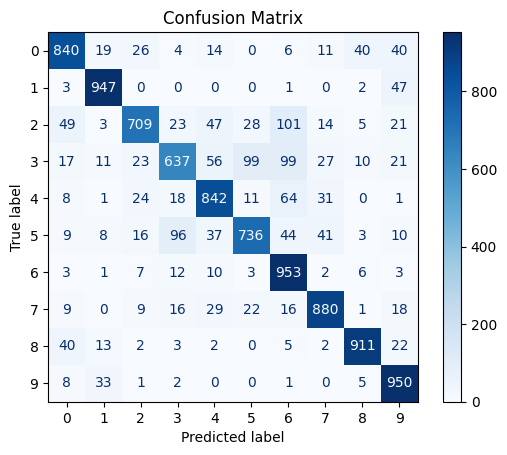

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Prediksi seluruh data uji
Y_pred = model.predict(X_test)

# Mengubah probabilitas menjadi label kelas
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        Y_true,
        Y_pred_classes,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

    airplane     0.8519    0.8400    0.8459      1000
  automobile     0.9141    0.9470    0.9303      1000
        bird     0.8678    0.7090    0.7804      1000
         cat     0.7855    0.6370    0.7035      1000
        deer     0.8120    0.8420    0.8267      1000
         dog     0.8187    0.7360    0.7751      1000
        frog     0.7388    0.9530    0.8323      1000
       horse     0.8730    0.8800    0.8765      1000
        ship     0.9268    0.9110    0.9188      1000
       truck     0.8385    0.9500    0.8908      1000

    accuracy                         0.8405     10000
   macro avg     0.8427    0.8405    0.8380     10000
weighted avg     0.8427    0.8405    0.8380     10000



Saving images (1).jpeg to images (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step


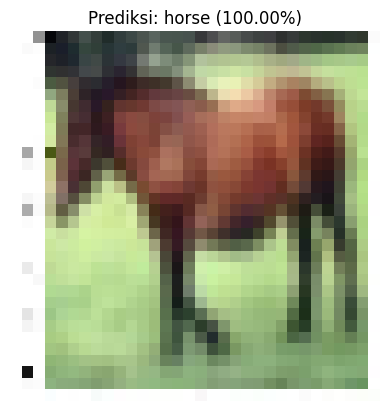

In [ ]:
# Prediksi Gambar dari Upload
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files


# Upload gambar
uploaded = files.upload()

for filename in uploaded.keys():
    # Load gambar & resize ke 32x32 (ukuran input model)
    img = image.load_img(filename, target_size=(32, 32))
    img_array = image.img_to_array(img)

    # Normalisasi sama seperti data training
    img_array = img_array.astype("float32") / 255.0

    # Tambah dimensi batch: (32,32,3) -> (1,32,32,3)
    img_batch = np.expand_dims(img_array, axis=0)

    # Prediksi
    pred = model.predict(img_batch)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    # Tampilkan hasil
    plt.imshow(img_array)
    plt.title(f"Prediksi: {class_names[pred_class]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()